In [3]:
# CELL 1: SETUP
!pip install PyMuPDF requests beautifulsoup4 nltk wordcloud matplotlib torch scikit-learn

import nltk
from google.colab import files
import os

# Download required NLTK resources silently (added punkt_tab)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Use the exact folder name from your original codebase
input_dir = "content"
os.makedirs(input_dir, exist_ok=True)

print(f"Setup complete! Folder '{input_dir}' is ready.")
print(f"ACTION REQUIRED: Upload your downloaded IIT Jodhpur PDFs and your text file with URLs directly into the '{input_dir}' folder.")

Setup complete! Folder 'content' is ready.
ACTION REQUIRED: Upload your downloaded IIT Jodhpur PDFs and your text file with URLs directly into the 'content' folder.


Starting data extraction and preparation...

Processing PDF: Resource Guide.pdf
Processing PDF: Office of Director _ IIT Jodhpur.pdf
Processing PDF: SoLA Newsletter 2025.pdf
Processing PDF: Academic Regulations _ Office of Academics Affairs _ IIT Jodhpur (1).pdf
Processing PDF: btech_cse.pdf

DATASET STATISTICS
Total Number of Documents Processed: 5
Total Number of Tokens: 12366
Vocabulary Size (Unique Tokens): 2378

Generating Word Cloud and saving files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

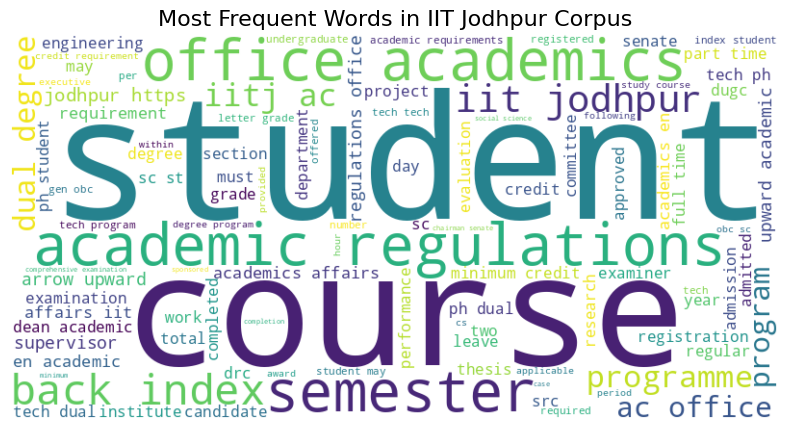

In [4]:
# CELL 2: DATASET PREPARATION & DOWNLOAD
import re
import fitz
import requests
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import json

def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        with fitz.open(pdf_path) as doc:
            for page in doc:
                text += page.get_text() + " "
    except Exception as e:
        print(f"Error reading PDF {pdf_path}: {e}")
    return text

def extract_text_from_url(url):
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url.strip(), headers=headers, timeout=10)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')
        elements = soup.find_all(['p', 'li', 'h1', 'h2', 'h3'])
        return " ".join([elem.get_text(strip=True) for elem in elements])
    except Exception as e:
        print(f"Error fetching URL {url}: {e}")
        return ""

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    clean_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    return clean_tokens

# --- MAIN EXECUTION PIPELINE ---
folder_path = "content"
all_corpus_tokens = []
total_documents = 0

print("Starting data extraction and preparation...\n")

for filename in os.listdir(folder_path):
    filepath = os.path.join(folder_path, filename)

    # Handle PDFs
    if filename.lower().endswith(".pdf"):
        print(f"Processing PDF: {filename}")
        raw_text = extract_text_from_pdf(filepath)
        if raw_text:
            tokens = preprocess_text(raw_text)
            all_corpus_tokens.extend(tokens)
            total_documents += 1

    # Handle the text file containing URLs
    elif filename.lower().endswith(".txt"):
        print(f"Found URL list: {filename}")
        with open(filepath, 'r', encoding='utf-8') as file:
            urls = file.readlines()

        for url in urls:
            url = url.strip()
            if url:
                print(f"  Fetching URL: {url}")
                raw_text = extract_text_from_url(url)
                if raw_text:
                    tokens = preprocess_text(raw_text)
                    all_corpus_tokens.extend(tokens)
                    total_documents += 1

# --- STATISTICS AND REPORTING ---
total_tokens = len(all_corpus_tokens)
vocabulary_size = len(set(all_corpus_tokens))

print("\n" + "="*30)
print("DATASET STATISTICS")
print("="*30)
print(f"Total Number of Documents Processed: {total_documents}")
print(f"Total Number of Tokens: {total_tokens}")
print(f"Vocabulary Size (Unique Tokens): {vocabulary_size}")

if total_tokens > 0:
    print("\nGenerating Word Cloud and saving files...")

    # Save and download Corpus
    with open("corpus.txt", "w", encoding="utf-8") as f:
        f.write(" ".join(all_corpus_tokens))
    files.download("corpus.txt")

    # Save and download JSON
    with open("cleaned_tokens.json", "w") as f:
        json.dump(all_corpus_tokens, f)
    files.download("cleaned_tokens.json")

    # Generate and download Word Cloud
    text_for_cloud = " ".join(all_corpus_tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=100).generate(text_for_cloud)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Most Frequent Words in IIT Jodhpur Corpus", fontsize=16)
    plt.savefig("wordcloud_output.png")
    files.download("wordcloud_output.png")
    plt.show()

else:
    print("\nNo tokens were extracted. Please ensure your PDFs and URL .txt file are directly inside the 'content' folder.")

In [5]:
# CELL 3: MODEL DEFINITIONS
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import Counter
import numpy as np

class TextCorpusDataset:
    def __init__(self, token_list, min_freq=5):
        self.token_list = token_list
        self._build_vocabulary(min_freq)
        self._setup_negative_sampling()

    def _build_vocabulary(self, min_freq):
        freq_counts = Counter(self.token_list)
        self.vocab = [w for w, c in freq_counts.items() if c >= min_freq]
        self.w2i = {w: i for i, w in enumerate(self.vocab)}
        self.i2w = {i: w for w, i in self.w2i.items()}
        self.vocab_size = len(self.vocab)
        self.corpus_data = [self.w2i[w] for w in self.token_list if w in self.w2i]

    def _setup_negative_sampling(self):
        counts = np.array([self.token_list.count(self.i2w[i]) for i in range(self.vocab_size)])
        probabilities = counts ** 0.75
        self.neg_probs = probabilities / sum(probabilities)

    def sample_negatives(self, count):
        return np.random.choice(self.vocab_size, size=count, p=self.neg_probs, replace=True).tolist()

    def get_batches(self, win_size, neg_count, b_size, cbow_mode=False):
        trgts, ctxs, negs = [], [], []

        for i in range(win_size, len(self.corpus_data) - win_size):
            center = self.corpus_data[i]
            surrounding = self.corpus_data[i - win_size : i] + self.corpus_data[i + 1 : i + win_size + 1]

            if cbow_mode:
                trgts.append(center)
                ctxs.append(surrounding)
                negs.append(self.sample_negatives(neg_count))
            else:
                for ctx in surrounding:
                    trgts.append(center)
                    ctxs.append(ctx)
                    negs.append(self.sample_negatives(neg_count))

            if len(trgts) >= b_size:
                yield torch.tensor(trgts), torch.tensor(ctxs), torch.tensor(negs)
                trgts, ctxs, negs = [], [], []

class SkipGramNet(nn.Module):
    def __init__(self, v_size, emb_dim):
        super().__init__()
        self.in_matrix = nn.Embedding(v_size, emb_dim)
        self.out_matrix = nn.Embedding(v_size, emb_dim)

    def forward(self, target, context, negative):
        vt = self.in_matrix(target)
        vc = self.out_matrix(context)
        vn = self.out_matrix(negative)

        p_score = torch.sum(vt * vc, dim=1)
        p_loss = -F.logsigmoid(p_score)

        n_score = torch.bmm(vn, vt.unsqueeze(2)).squeeze(2)
        n_loss = -torch.sum(F.logsigmoid(-n_score), dim=1)

        return torch.mean(p_loss + n_loss)

class CBOWNet(nn.Module):
    def __init__(self, v_size, emb_dim):
        super().__init__()
        self.in_matrix = nn.Embedding(v_size, emb_dim)
        self.out_matrix = nn.Embedding(v_size, emb_dim)

    def forward(self, target, contexts, negative):
        v_ctxs = self.in_matrix(contexts)
        v_ctx_mean = torch.mean(v_ctxs, dim=1)

        vt = self.out_matrix(target)
        vn = self.out_matrix(negative)

        p_score = torch.sum(v_ctx_mean * vt, dim=1)
        p_loss = -F.logsigmoid(p_score)

        n_score = torch.bmm(vn, v_ctx_mean.unsqueeze(2)).squeeze(2)
        n_loss = -torch.sum(F.logsigmoid(-n_score), dim=1)

        return torch.mean(p_loss + n_loss)

In [6]:
# CELL 4: EVALUATION & VISUALIZATION
from sklearn.manifold import TSNE
import itertools

def find_closest_words(net, w2i, i2w, query_word, k=5):
    if query_word not in w2i:
        return f"'{query_word}' missing from vocab."

    weights = net.in_matrix.weight.data
    q_vec = weights[w2i[query_word]]

    sims = F.cosine_similarity(q_vec.unsqueeze(0), weights)
    vals, idxs = torch.topk(sims, k + 1)

    return [(i2w[idx.item()], round(val.item(), 4)) for idx, val in zip(idxs[1:], vals[1:])]

def solve_word_analogy(net, w2i, i2w, w1, w2, w3, k=1):
    if not all(w in w2i for w in [w1, w2, w3]):
        return "Vocabulary missing for this analogy."

    weights = net.in_matrix.weight.data
    v1, v2, v3 = weights[w2i[w1]], weights[w2i[w2]], weights[w2i[w3]]

    target_vec = v2 - v1 + v3
    sims = F.cosine_similarity(target_vec.unsqueeze(0), weights)
    vals, idxs = torch.topk(sims, k + 4)

    res = []
    for idx, val in zip(idxs, vals):
        word = i2w[idx.item()]
        if word not in [w1, w2, w3]:
            res.append((word, round(val.item(), 4)))
            if len(res) == k: break
    return res

def plot_2d_embeddings(net, w2i, display_words, save_name):
    vecs, labels = [], []
    for w in display_words:
        if w in w2i:
            vecs.append(net.in_matrix.weight.data[w2i[w]].cpu().numpy())
            labels.append(w)

    if len(labels) < 5: return

    perp = min(30, len(labels) - 1)
    reducer = TSNE(n_components=2, perplexity=perp, random_state=42)
    embeddings_2d = reducer.fit_transform(np.array(vecs))

    plt.figure(figsize=(10, 8))
    for i, w in enumerate(labels):
        plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], c='purple', alpha=0.7)
        plt.text(embeddings_2d[i, 0] + 0.02, embeddings_2d[i, 1] + 0.02, w, fontsize=11)

    plt.title("t-SNE Projection of Word Embeddings", fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(save_name)
    plt.close() # Close to prevent overlapping plots

In [10]:
# CELL 5: TRAINING, EVALUATION & DOWNLOAD
import zipfile

def train_routine(loader, architecture, dim, win, neg, eps=3, b_size=512):
    if architecture == "skipgram":
        net = SkipGramNet(loader.vocab_size, dim)
        is_cbow = False
    else:
        net = CBOWNet(loader.vocab_size, dim)
        is_cbow = True

    opt = optim.Adam(net.parameters(), lr=0.01)

    for ep in range(eps):
        t_loss, b_cnt = 0, 0
        for trgt, ctx, n_samples in loader.get_batches(win, neg, b_size, is_cbow):
            opt.zero_grad()
            loss = net(trgt, ctx, n_samples)
            loss.backward()
            opt.step()
            t_loss += loss.item()
            b_cnt += 1
        print(f"    Epoch {ep+1}/{eps} - Loss: {t_loss / b_cnt:.4f}")
    return net

# --- Execution Block ---
with open("corpus.txt", "r", encoding="utf-8") as f:
    tokens = f.read().split()

dataset = TextCorpusDataset(tokens)

# Assignment Requirements
target_words = ["research", "student", "phd", "exam"]
analogy_tests = [
    ("ug", "btech", "pg"),
    ("faculty", "teaching", "student"),
    ("technology", "engineering", "science")
]
plot_words = ["research", "student", "phd", "exam", "course", "faculty", "btech", "mtech",
              "ug", "pg", "institute", "technology", "science", "engineering", "computer",
              "semester", "grade", "hostel", "fee", "admission", "project", "thesis"]

generated_plots = []

for m_type, win_size in itertools.product(["skipgram", "cbow"], [2, 4]):
    print(f"\nTraining {m_type.upper()} | Window: {win_size} | Dim: 50 | Negatives: 5")

    trained_net = train_routine(dataset, m_type, 50, win_size, 5, eps=20)

    print("\n  [+] Top 5 Nearest Neighbors:")
    for w in target_words:
        if w in dataset.w2i:
            print(f"      {w} -> {find_closest_words(trained_net, dataset.w2i, dataset.i2w, w)}")

    print("\n  [+] Analogy Experiments:")
    for a, b, c in analogy_tests:
        res = solve_word_analogy(trained_net, dataset.w2i, dataset.i2w, a, b, c, k=3)
        print(f"      {a} : {b} :: {c} : ? -> {res}")

    plot_file = f"plot_{m_type}_w{win_size}.png"
    plot_2d_embeddings(trained_net, dataset.w2i, plot_words, plot_file)
    generated_plots.append(plot_file)

# Zip and download all generated plots
zip_filename = "visualizations.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for plot in generated_plots:
        zipf.write(plot)

print(f"\nDone! Downloading {zip_filename} with all visualization charts.")
files.download(zip_filename)


Training SKIPGRAM | Window: 2 | Dim: 50 | Negatives: 5
    Epoch 1/20 - Loss: 14.4646
    Epoch 2/20 - Loss: 9.6480
    Epoch 3/20 - Loss: 6.3145
    Epoch 4/20 - Loss: 4.3573
    Epoch 5/20 - Loss: 3.4153
    Epoch 6/20 - Loss: 2.8991
    Epoch 7/20 - Loss: 2.5657
    Epoch 8/20 - Loss: 2.3638
    Epoch 9/20 - Loss: 2.2076
    Epoch 10/20 - Loss: 2.1013
    Epoch 11/20 - Loss: 2.0060
    Epoch 12/20 - Loss: 1.9416
    Epoch 13/20 - Loss: 1.8907
    Epoch 14/20 - Loss: 1.8448
    Epoch 15/20 - Loss: 1.8043
    Epoch 16/20 - Loss: 1.7760
    Epoch 17/20 - Loss: 1.7423
    Epoch 18/20 - Loss: 1.7176
    Epoch 19/20 - Loss: 1.6935
    Epoch 20/20 - Loss: 1.6751

  [+] Top 5 Nearest Neighbors:
      research -> [('school', 0.4587), ('interaction', 0.4583), ('campus', 0.452), ('approved', 0.432), ('enrolled', 0.4304)]
      student -> [('another', 0.5276), ('absence', 0.5166), ('required', 0.4828), ('based', 0.4309), ('addition', 0.4288)]
      phd -> [('general', 0.4932), ('master', 0.489

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>